In [4]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import gprob as gp

gp.rn.seed(0)  # To make the sampling reproducible.

# Introduction

A linear stochastic differential equation (SDE) is a relation of the kind
$$
\dot{\vec{x}}=\mathbf{A} \vec{x} + \vec{f},
$$
which describes the time evolution of a $k$-dimensional vector $\vec{x}$ driven by a random force $\vec{f}$.
The time derivative of $\vec{x}$ here is denoted as $\dot{\vec{x}}$, and $\mathbf{A} \vec{x}$ means the vector $\vec{x}$ multiplied by a $k\times k$ matrix $\mathbf{A}$, which can be dependent on time. When $\vec{f}$ is a Gaussian noise process, the solution $\vec{x}$ of the SDE is a Gaussian process as well. 

Similarly to ordinary differential equations (ODEs), SDEs can be solved approximately via time discretization. The error of the solution $\varepsilon$ scales with the discretization time step $\Delta t$ as $\varepsilon\propto\Delta t^n$, where the power $n$ depends on the solution method and is referred to as convergence order. While many standard schemes for the solution of ODEs, such as Runge-Kutta, have $n$ between $4$ and $12$, for SDEs it is not at all straighforward to come by a scheme that has $n>2$. A second order scheme is also the one that comes built-in with gprob (`sde` from the `integrate` module), while we also will see a scheme of the order four at the end of this notebook. For further theory of the subject, a good reference is the book of P. E. Kloeden and E. Platen [Numerical Solution of Stochastic Differential Equations.](https://doi.org/10.1007/978-3-662-12616-5) (Springer, Berlin, Heidelberg, 1992).


# A simple example

To begin with, we will make the concepts of the solution error and convergence order more tangible by considering a simple analytically solvable example - the Ornstein–Uhlenbeck process. In the language of SDEs, the problem is expressed as
\begin{align*}
&\dot{x}(t)=-x(t) + f(t),
&x(0)=x_0,
\end{align*}
where $x_0$ is the inital condition, and $f(t)$ is a white noise process with the correlation function $\langle f(t+\tau)f(t) \rangle=\delta(\tau)$. The correlation function of the solution $x(t)$, when $x_0$ is independent of $f(t)$, can be shown to be
\begin{equation*}
\left\langle x(t_1) x(t_2)\right\rangle = \left\langle x_0^2\right\rangle e^{-(t_1+t_2)}+\frac{1}{2}\left(e^{-|t_1-t_2|}-e^{-(t_1+t_2)}\right).
\end{equation*}

Probably the simplest way to numerically approximate the solution $x(t)$ is by applying the Euler's rule to the original SDE.
One important technicality here is that $f$ itself is poorly suitable for time discretization, as its correlation function diverges at zero time. This is not an issue if the SDE is represented in the incremental form, 
$$
dx=-x(t)dt + df,
$$
where $dt$ is a small time step, $dx=x(t+dt)-x(t)$, and $df=\int_{t}^{t+dt}f(s)ds$ are called the Wiener increments. In this representation, all the random variables involved have finite statistical moments.
The discrete version of the SDE in this form is
$$
x_{i+1}- x_{i}=-x_i\,(t_{i+1} - t_{i}) + df_i,
$$
which allows iteratively calculating $x_{i+1}$ at the next time $t_{i+1}$ from $x_{i}$ at the previous time $t_i$ and the integral of the force $df_i$ between $t_i$ and $t_{i+1}$.
The Euler scheme has the convergence order 1. This means that if we define the solution error as the maximum relative deviation of its covariance matrix from the true covariance, this error will reduce with the refinement of the time grid proportional to $\max_i\left|t_{i+1} - t_{i}\right|$. 

Another scheme to approximate the same SDE,
$$
x_{i+1} - x_{i} = -\frac{1}{2}\left(x_{i+1} + x_{i}\right)(t_{i+1}-t_i)+df_i,
$$
will have a higher convergence order, namely 2. I will call this scheme after Platen, an author of the textbook mentioned in the introduction. (As a disclaimer - I do not know whether Platen invented this scheme, and Euler did not solve any SDEs using the scheme named after him above.)

The numerical schemes presented above can be implemented as follows

In [5]:
def cov_ou(x0, t):
    """The true covariance matrix of the Ornstein–Uhlenbeck process."""
    t1 = np.reshape(t, (len(t), 1))
    t2 = np.reshape(t, (1, len(t)))
    e1 = np.exp(-(t1 + t2))
    e2 = np.exp(-np.abs(t1 - t2))
    return gp.var(x0) * e1 + (e2 - e1) / 2


def error(tcov, cov):
    """The solution error."""
    return np.max(np.abs(1 - cov / tcov))


def euler_ou(x0, t, df):
    """Euler scheme approximation of the Ornstein–Uhlenbeck process."""
    x = [x0] * len(t)
    for i in range(len(t)-1):
        x[i+1] = x[i] - x[i] * (t[i+1] - t[i]) + df[i]
    return gp.stack(x)


def platen_ou(x0, t, df):
    """Platen scheme approximation of the Ornstein–Uhlenbeck process."""
    x = [x0] * len(t)
    for i in range(len(t)-1):
        dth = (t[i+1] - t[i]) / 2
        x[i+1] = (x[i] - x[i] * dth + df[i]) / (1 + dth)
    return gp.stack(x)

To compare the Euler and Platen schemes, we can calculate the error of the solution $x$ over a range of time grid sizes `sz`. Larger size means more time steps and smaller $dt$.

In [6]:
szs = [int(2**p) - 1 for p in np.linspace(np.log2(11), np.log2(1001), 10)]  # grid sizes
x0 = gp.normal(0, 1e-2)  # initial condition

err1 = []  # errors of the Euler scheme
err2 = []  # errors of the Platen scheme

for sz in szs:
    t = np.linspace(0, 1, sz + 1)  # time grid
    dt = t[1:] - t[:-1]  # time increments
    df = gp.normal(size=sz) * np.sqrt(dt)  # Wiener increments
    
    x = euler_ou(x0, t, df)
    err1.append(error(cov_ou(x0, t), x.cov()))

    x = platen_ou(x0, t, df)
    err2.append(error(cov_ou(x0, t), x.cov()))

# The convergence orders are the error slopes.
print(f"n_Eu: {np.log(err1[-3] / err1[-2]) / np.log(szs[-2] / szs[-3]):0.2}")
print(f"n_Pl: {np.log(err2[-3] / err2[-2]) / np.log(szs[-2] / szs[-3]):0.2}")

n_Eu: 1.0
n_Pl: 2.0


Visualizing the results,

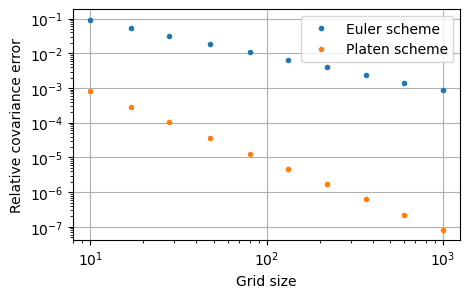

In [7]:
plt.figure(figsize=(5, 3.))
plt.plot(szs, err1, ls="None", marker=".", label="Euler scheme")
plt.plot(szs, err2, ls="None", marker=".", label="Platen scheme")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Grid size")
plt.ylabel("Relative covariance error")
plt.legend()
plt.grid();

# `integrate.sde`

gprob includes the vector version of the Platen scheme implemented in an optimized way in the function `integrate.sde`. Below there are some examples of the application of this function to time-dependent problems and problems involving non-white noise drives, for most of which no explicit analytical solution exists. (The solution of a linear SDE can always be expressed as an integral - see the Green's function section below - but this integral in general cannot be evaluated analytically.)

## Time dependence

For an example of a scalar SDE that has time-dependent drift and diffusion cofficients we will take 
$$\dot{x}(t)=a(t)x(t)+b(t)f(t),$$
where $f(t)$ is a stationary white noise, $\langle f(t+\tau)f(t) \rangle=\delta(\tau)$, $a(t)=\sin(5t/2)$, and $b(t)=\cos(4t)$.

The Wiener increments of the driving force, $b(t)f(t)$, can be calculated with sufficient precision by using the trapezoidal rule,
$$\int_{t_i}^{t_{i+1}}b(t)f(t)dt\approx \frac{1}{2}\left(b(t_{i+1})+b(t_{i})\right)df_i.$$
Note that the endpoint rule, $b(t_{i})df_i$, would not be good enough - it would reduce the convergence order to 1.

The whole solution of the problem looks as follows.

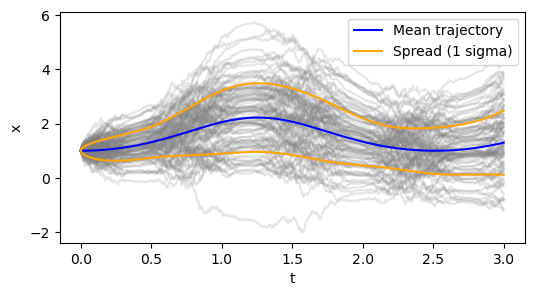

In [8]:
# A time grid spanning from t=0 to t=3. The non-uniformity is just for fun.
t = np.linspace(0, np.sqrt(3), 1001)**2
dt = t[1:] - t[:-1]

a = lambda t: np.sin(2.5 * t)  # drift coefficient
b = np.cos(4 * t)  # diffusion coefficient

b_ = 0.5 * (b[1:] + b[:-1])  # midpoint b
dbf = b_ * gp.normal(size=len(dt)) * np.sqrt(dt)
x0 = 1  # initial condition

x = gp.integrate.sde(x0, t, a, dbf)

ns = 100  # number of samples for plotting

_ = plt.figure(figsize=(6, 3))
plt.plot(t, x.sample(ns).T, color="gray", alpha=0.2)
plt.plot(t, x.mean(), color="blue", label="Mean trajectory")
plt.plot(t, x.mean() + x.std(), color="orange", label="Spread (1 sigma)")
plt.plot(t, x.mean() - x.std(), color="orange")
plt.xlabel("t")
plt.ylabel("x")
plt.legend();

To add a deterministic component to the driving force, for example $g(t)=-\exp(t/2)$, one can also use the trapezoidal rule.

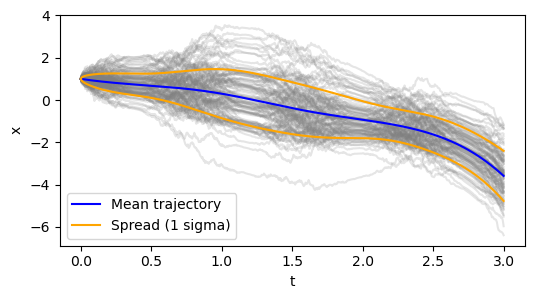

In [9]:
g = - np.exp(0.5 * t)
dg = 0.5 * (g[1:] + g[:1]) * dt

x = gp.integrate.sde(x0, t, a, dbf + dg)

_ = plt.figure(figsize=(6, 3))
plt.plot(t, x.sample(ns).T, color="gray", alpha=0.2)
plt.plot(t, x.mean(), color="blue", label="Mean trajectory")
plt.plot(t, x.mean() + x.std(), color="orange", label="Spread (1 sigma)")
plt.plot(t, x.mean() - x.std(), color="orange")
plt.xlabel("t")
plt.ylabel("x")
plt.legend();

## Non-write input noises

Unlike the case of white noise drive, when the driving force $f$ is correlated at different times according to a non-sigular correlation function $C$,  
$$\langle f(t)f(t')\rangle=C(t, t'),$$
there is no problem discretizing it directly into an array of random variables $f(t_i)$. The force increments then can be found with sufficent precision using the trapezoidal rule,
$$
df_i = \frac{1}{2}\left(f(t_{i+1})+f(t_i)\right)dt_i.
$$

For an example problem with this type of noisy drive, we will take the equation
$$\dot{x}(t)=a(t)x(t)+f(t),$$
with the force correlation function $C(t, t')=e^{t_1^2/2+t_2^2/2-|t_1-t_2|}$ and $a(t)=t$. The parameters $C$ and $a$ are picked such that there is an analytical solution to the SDE,
$$\langle x(t_1) x(t_2)\rangle=e^{(t_1^2+t_2^2)/2}\left(\langle x_0^2 \rangle +e^{-t_1}+e^{-t_2}-e^{-|t_1-t_2|} + 2 \min(t_1, t_2) - 1\right).$$
(As previously, it was assumed that $x_0$ is independent of $f$.)

In [1]:
def cov_nw(x0, t):
    """Covariance of the analytical solution"""
    t1 = np.reshape(t, (len(t), 1))
    t2 = np.reshape(t, (1, len(t)))

    e1 = np.exp((t1**2 + t2**2) / 2)
    e2 = (np.exp(-t1) + np.exp(-t2) - np.exp(-np.abs(t1 - t2)) 
          + 2 * np.minimum(t1, t2) - 1)

    return e1 * (gp.var(x0) + e2)


def cov_f(t):
    """Covariance the force."""
    t1 = np.reshape(t, (len(t), 1))
    t2 = np.reshape(t, (1, len(t)))
    return np.exp((t1**2 + t2**2) / 2 - np.abs(t1-t2))


t = np.linspace(0, 1, 1001)  # time grid
dt = t[1:] - t[:-1]

a = lambda t: t  # drift coefficient
f = gp.normal(0, cov_f(t))  # driving force
df = (f[1:] + f[:-1]) * dt / 2  # Wiener increments
x0 = gp.normal(-1, 0.5)  # initial condition

x = gp.integrate.sde(x0, t, a, df)

print(f"Numerical solution error: {error(cov_nw(x0, t), x.cov()):0.5}")

ns = 100

_ = plt.figure(figsize=(6, 3))
plt.plot(t, x.sample(ns).T, color="gray", alpha=0.2)
plt.plot(t, x.mean(), color="blue", label="Mean trajectory")
plt.plot(t, x.mean() + x.std(), color="orange", label="Spread (1 sigma)")
plt.plot(t, x.mean() - x.std(), color="orange")
plt.xlabel("t")
plt.ylabel("x")
plt.legend();

NameError: name 'np' is not defined

Note that the trajectories of $x$ look smooth in this example - without divergence in the correlation function of $f(t)$, the derivatives of $x(t)$ are continuous.

## Vector SDEs

For an example of a higher-dimensional problem, we will take the Brownian motion of a harmonic oscillator,
$$\ddot{x}+\gamma \dot{x}+\omega^2 x=f,$$
where $f$ is a white noise, $\langle f(t+\tau)f(t) \rangle=\delta(\tau)$.
By introducing the oscillator momentum $p=\dot{x}$, the second order scalar equation describing the harmonic motion becomes a first-order vector equation,

\begin{align*}
&\dot{\vec{x}}=\mathbf{A}\vec{x}+\vec{f},&

&\text{where}&

&\vec{x}=\begin{pmatrix}
x \\
p
\end{pmatrix},&

&\vec{f}=\begin{pmatrix}
0 \\
f
\end{pmatrix},&

&\mathbf{A}=
\begin{pmatrix}
0 & 1 \\
-\omega^2 & -\gamma
\end{pmatrix}.
\end{align*}

This is solved as


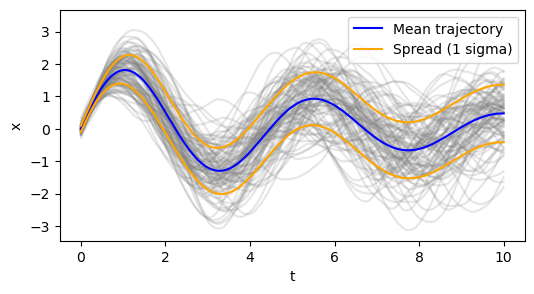

In [11]:
t = np.linspace(0, 10, 1001)  # time grid
dt = t[1:] - t[:-1]

gamma = 0.3
omega_sq = 2

a = lambda t: [[0, 1], [-omega_sq, -gamma]]
df = [np.zeros(len(dt)), gp.normal(size=len(dt)) * np.sqrt(dt)]
x0 = [gp.normal(0, 1e-2), 3]

x = gp.integrate.sde(x0, t, a, df)

ns = 100
x_ = x[0]  # x[0] is the position, x[1] is the momentum

_ = plt.figure(figsize=(6, 3))
plt.plot(t, x_.sample(ns).T, color="gray", alpha=0.2)
plt.plot(t, x_.mean(), color="blue", label="Mean trajectory")
plt.plot(t, x_.mean() + x_.std(), color="orange", label="Spread (1 sigma)")
plt.plot(t, x_.mean() - x_.std(), color="orange")
plt.xlabel("t")
plt.ylabel("x")
plt.legend();

## Cascading equations

In situations where the driving force has a non-tivial correlation function, one may have its expression as a solution of another SDE.
For a concrete example, consider the system
\begin{align*}
&\dot{x}(t)=-x(t)+f(t),\\
&y(t)=\eta(t) + b(t)x(t),\\
&\dot{z}(t)=-z(t)+c(t)y(t),
\end{align*}
where $b(t)=1 + t/2$ and $c(t)=1/2 - t^2$ are time-dependent coefficients, $\eta(t)=f(t)+\xi(t)$, and $f(t)$ and $\xi(t)$ are independent white noises. Here in the equation for $z(t)$ the driving force $c(t)y(t)$ is a linear function of $x(t)$, which in its turn is the solution of another equation. (As a side note, relations such as the one between $x$ and $y$ are relevant to control theory, where $y$ would represent noisy measurements made on $x$ with the uncertainty $\eta$.)

The above system of equations can be solved as one vector SDE if we substitute $y$ from the middle equation into the equation for $z$. Alternatively, it can be solved in a cascaded way - the equation for $x$ is solved first, then $y$ is calculated from $x$, and then $z$ is calculated from $y$. The last two steps require finding integral increments, which can be done using the trapezoidal rule.

The advantages of the cascaded approach include better transparency and the possibility of obtaining conditional values and correlations between all intermediate variables - e.g. $x$ and $y$, or $z$ and $y$. The cascaded solution is implemented below.

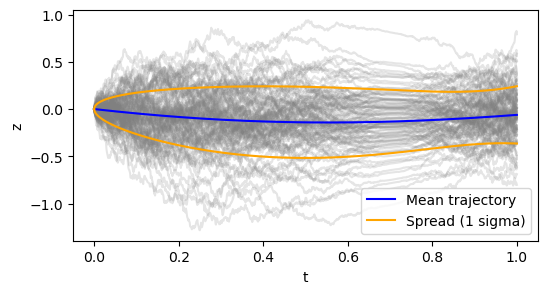

In [27]:
t = np.linspace(0, 1, 1001)  # time grid
t_ = 0.5 * (t[1:] + t[:-1])
dt = t[1:] - t[:-1]

df = gp.normal(size=len(dt)) * np.sqrt(dt)
x0 = gp.normal(-1, 0.5)

x = gp.integrate.sde(x0, t, lambda t: -1, df)

dxi = gp.normal(size=len(dt)) * np.sqrt(dt)
b = lambda t: 1 + 0.5 * t  # b(t)
dy = df + dxi + b(t_) * 0.5 * (x[1:] + x[:-1]) * dt

c = lambda t: 0.5 - t**2  # c(t)
dcy = c(t_) * dy
z0 = 0

z = gp.integrate.sde(z0, t, lambda t: -1, dcy)

ns = 100

_ = plt.figure(figsize=(6, 3))
plt.plot(t, z.sample(ns).T, color="gray", alpha=0.2)
plt.plot(t, z.mean(), color="blue", label="Mean trajectory")
plt.plot(t, z.mean() + z.std(), color="orange", label="Spread (1 sigma)")
plt.plot(t, z.mean() - z.std(), color="orange")
plt.xlabel("t")
plt.ylabel("z")
plt.legend();

Comparing the cascaded solution with the vector approach,

In [28]:
v0 = [x0, z0]
av = lambda t: [[-1, 0], [c(t) * b(t), -1]]
dfv = [df, c(t_) * (df + dxi)]
v = gp.integrate.sde(v0, t, av, dfv)

print(f"Solution discrepancy: {np.max(np.abs(gp.cov([x, z]) - gp.cov(v))):0.5}")

Solution discrepancy: 1.206e-07


# Green's function

This section presents an alternative approach to the time-discretization of SDEs, and provides the necessary preliminaries for the next section, where we will derive a numerical scheme with a higher order of convergence.

The solution of a $k$-dimensional linear vector SDE,
$$
\dot{\vec{x}}(t)=\mathbf{A}(t)\, \vec{x}(t) + \vec{f}(t),
$$
can be expressed as

$$\vec{x}(t)= \mathbf{G}(t,0)\,\vec{x}(0) + \int_{0}^{t}\mathbf{G}(t,t')\vec{f}(t')dt',$$

where $\mathbf{G}(t_2, t_1)$ is a $k$ by $k$ matrix of functions of two time variables - the Green's function,

$$\mathbf{G}(t_2, t_1) = \exp\left(\int_{t_1}^{t_2}\mathbf{A} dt'\right).$$

Although being a function of two time variables, $t_1$ and $t_2$, the Green's function obeys the relation
$$\mathbf{G}(t_2, t_1) = \mathbf{G}(t_2, 0)\,\mathbf{G}^{-1}(t_1, 0),$$
where $\mathbf{G}^{-1}(t_1, 0)$ is the matrix inverse of $\mathbf{G}(t_1, 0)$, and therefore it is sufficiently to know only $\mathbf{G}(t, 0)$ and its inverse to be able to express $\mathbf{G}(t_2, t_1)$. Denoting the single-parameter Green's function as $\mathbf{G}(t)\equiv\mathbf{G}(t, 0)$, the solution of the SDE is expressed as

$$\vec{x}(t)= \mathbf{G}(t)\left(\vec{x}(0) + \int_{0}^{t}\mathbf{G}^{-1}(t')\vec{f}(t')dt'\right).$$

The columns of $\mathbf{G}(t)$ are the solutions of the homogeneous differential equation with the initial coditions spanning the $k$ unit vectors, i.e. $\vec{x}(0)=(1, 0, ...)^T$, $\vec{x}(0)=(0, 1, ...)^T$ and so on, which provides a convenient and efficient way to numerically compute $\mathbf{G}(t)$.

To illustrate the idea, we repeat the solution of the harmonic oscillator problem using the Green's function menthod.

In [14]:
def sde_g(x0, t, a, df):
    """Solves an initial value problem for a vector SDE using 
    the Green's function method of second order."""

    def eqs(t, x): 
        return a(t) @ x

    k = len(x0)
    e = np.eye(k)

    green = [sp.integrate.solve_ivp(eqs, [t[0], t[-1]], y0, t_eval=t, 
                                    rtol=3e-14, atol=1e-14).y.T for y0 in e]
    green = np.stack(green, axis=-1)
    green_inv = np.linalg.inv(green)  # G^{-1}(t')
    green_inv = 0.5 * (green_inv[1:] + green_inv[:-1])

    s = gp.einsum("ikj, ji -> ik", green_inv, df)  # G^{-1}(t') @ df(t')
    s = gp.cumsum(s, axis=0)
    s = gp.concatenate([np.zeros((1, k)), s], axis=0)  # int(G^{-1}(t') @ f(t'))       

    return gp.einsum("ikj, ij -> ki", green, x0 + s)  # G(t) @ (x0 + s))


t = np.linspace(0, 10, 1001)
dt = t[1:] - t[:-1]

gamma = 0.3
omega_sq = 2

a = lambda t: [[0, 1], [-omega_sq, -gamma]]
df = [np.zeros(len(dt)), gp.normal(size=len(dt)) * np.sqrt(dt)]
x0 = [gp.normal(0, 1e-2), 10]

x = sde_g(x0, t, a, df)
x_ = gp.integrate.sde(x0, t, a, df)

# The difference between the two solutions.
np.max(np.abs(x_.cov() - x.cov())) / np.max(x_.cov())

5.563224352855773e-05

# A 4th order scheme

To produce a numerical scheme

$$dz_i=\int_{t_i}^{t_{i+1}}f(t)(t-\bar{t}_i)dt,$$

where $\bar{t}_i=(t_i + t_{i+1})/2$ is the midpoint time for the $i$-th interval.

$$\int_{t_i}^{t_{i+1}}\mathbf{G}^{-1}(t)\vec{f}(t)dt= \int_{t_{i}}^{t_{i+1}}\left(\mathbf{G}^{-1}(\bar{t}_i)+\frac{d\mathbf{G}^{-1}}{dt}(\bar{t}_i)\,(t-\bar{t}_i)+\frac{d^2\mathbf{G}^{-1}}{dt^2}(\bar{t}_i)\,\frac{(t-\bar{t}_i)^2}{2}+...\right)\vec{f}(t)dt$$

$$\vec{x}_i= \mathbf{G}(t_i)\left(\vec{x}_0 + \sum_{j=1}^{i}\left[\left(\mathbf{G}^{-1}(\bar{t}_i)+\frac{d^2\mathbf{G}^{-1}}{dt^2}(\bar{t}_i)\,\frac{dt_i^2}{24}\right)df_i+\frac{d\mathbf{G}^{-1}}{dt}(\bar{t}_i)dz_i\right]\right).$$

In [15]:
def sde_g4(x0, t, a, df, dz):
    """Solves an initial value problem for a scalar SDE,
    ``dx = a(t) * x * dt + df,  x[0] = x0,``
    using a 4th order scheme. 

    Args:
        x0 (numeric or Normal):
            The initial condition.
        t (array):
            The time grid, shape (n,).
        a (callable):
            The evolution factor as function of time.
        df (numeric or Normal):
            The Wiener increments of the driving force.
        dz:TODO
    
    Returns:
        Normal: A solution of the SDE ``x(t[i])`` with the shape (n,).
    """

    def ax(t, x):
        return a(t) * x
    
    sol = sp.integrate.solve_ivp(ax, [t[0], t[-1]], [1.], rtol=3e-14, atol=0)
    
    gr_f = sp.interpolate.make_interp_spline(sol.t, sol.y.squeeze(0), 5)
    gr_df = gr_f.derivative(1)
    gr_d2f = gr_f.derivative(2)

    t_ = 0.5 * (t[1:] + t[:-1])
    dt = (t[1:] - t[:-1])

    gr = gr_f(t)

    igr = 1 / gr_f(t_)
    gr_d = gr_df(t_)
    gr_d2 = gr_d2f(t_)

    igr_d = - gr_d * igr**2

    h = dt * (2 * gr_d**2 * igr - gr_d2) * igr  # == igr_d2 / igr
    igr_c = igr * (1 + h**2 / 24)
    
    s = gp.cumsum(igr_c * df + igr_d * dz)
    u = x0 + gp.concatenate([[0], s])
    x = gr * u

    return x

In [16]:
szs = [int(2**p) - 1 for p in np.linspace(np.log2(11), np.log2(1001), 10)]  # grid sizes
x0 = gp.normal(0, 1e-2)  # initial condition

err3 = []  # the Euler's scheme

for sz in szs:
    t = np.linspace(0, 1, sz + 1)  # time grid
    dt = t[1:] - t[:-1]  # time increments
    df = gp.normal(size=sz) * np.sqrt(dt)
    dz = gp.normal(size=len(dt)) * np.sqrt(dt**3 / 12)

    x = sde_g4(x0, t, lambda t: -1, df, dz)
    err3.append(error(cov_ou(x0, t), x.cov()))

# The convergence order.
print(f"n: {np.log(err3[-3] / err3[-2]) / np.log(szs[-2] / szs[-3]):0.2}")

n: 4.0


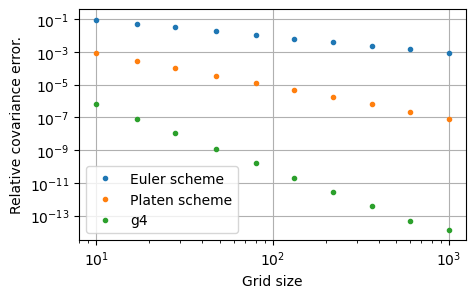

In [17]:
plt.figure(figsize=(5, 3.))
plt.plot(szs, err1, ls="None", marker=".", label="Euler scheme")
plt.plot(szs, err2, ls="None", marker=".", label="Platen scheme")
plt.plot(szs, err3, ls="None", marker=".", label="g4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Grid size")
plt.ylabel("Relative covariance error.")
plt.legend()
plt.grid();